# v2a reticulospinal neuron dataset of larva zebrafish 

The following analysis on this data is meant to demonstrate the analysis pipeline using the developed toolbox.

This data was already discussed in the paper by [Carbo-Tano et. al (2022)](https://www.biorxiv.org/content/biorxiv/early/2022/04/05/2022.04.01.486703.full.pdf)



The data was acquired using SCAPE at ~6 Hz. 

 

#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import load_data
from src.dataPreProcessing import replace_nan


# if variables are changed on the fly 
from reloading import reloading

In [2]:
%reload_ext autoreload
%autoreload 2
from src.tryParallel import *

### Load data

The data are provided in `.npy` file types. However, the `load_data()` function can load `.txt` as well as `pickle` files.

In [3]:
traces = load_data(r'./data/220119_F2_F2_run11_cells_fluorescence_signals.npy')
emitter_id = load_data(r'./data/220119_F2_F2_run11_emitter_cells.npy')
receiver_id = load_data(r'./data/220119_F2_F2_run11_receiver_cells.npy')
topography = load_data(r'./data/220119_F2_F2_run11_cells_positions.npy')
bad_frames = [13, 87, 88, 975, 1253, 1555, 1556, 1700, 1701, 1761, 2268, 3003]

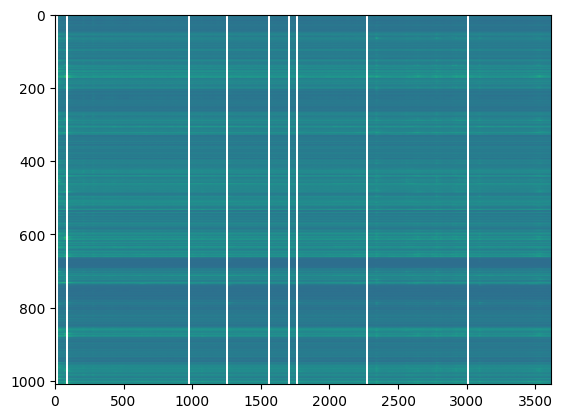

In [4]:
plt.imshow(traces, aspect= 'auto')

In [5]:
topography.shape

(1010, 3)

#### Data Preprocessing

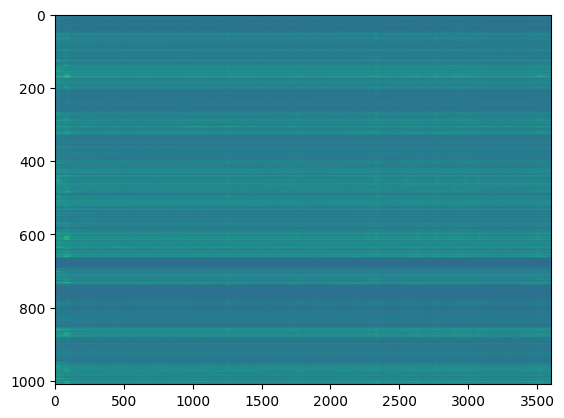

In [6]:
new_traces = replace_nan(traces, bad_frames, delete_frames=True)
plt.imshow(new_traces, aspect= 'auto')

#### Data exploration

After a minimal preprocessing on the data, we can then go ahead and do some data exploration

In [7]:
print(traces.shape)
print('')
print('')
print(new_traces.shape)

(1010, 3613)


(1010, 3601)


Select identified ROIs to be used in the analysis using the `emitter_id` and `receiver_id`

In [8]:
ER_idx = np.r_[emitter_id, receiver_id]

# extract the identified data and output the new data as X
X = new_traces[ER_idx]

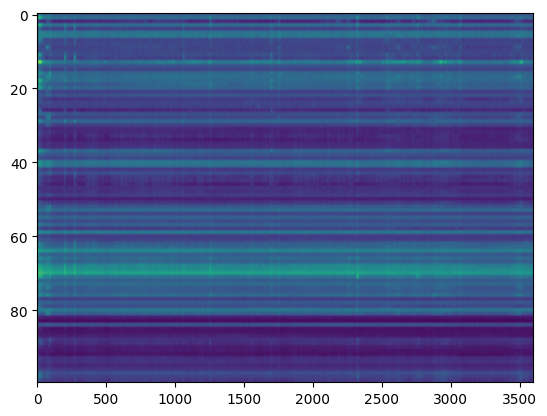

In [9]:
plt.imshow(X, aspect='auto')

### Causal Analysis

We instantiate the class with global variables such as the
   * number of permutation = 1000,
   * number of pasts states = 5,
   * number of lags = 3


In [10]:
gc_star = GcStar(n_perm = 1000, n_pasts = 5, n_lags = 3, temporal = True)

In [11]:
%%time
gc_star.fit(X, verbose = 1)

INFO:src.tryParallel:Starting correlation_func
INFO:src.tryParallel:Starting inv_correlation_func
INFO:src.tryParallel:Waiting for correlation_func and inv_correlation_func to complete
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/6000 (0.02% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/12000 (0.01% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/12000 (0.01% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/12000 (0.01% complete)
INFO:src.tryParallel:Step 1/12000 (0.01% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.tryParallel:Step 1/12000 (0.01% complete)
INFO:src.tryParallel:Step 1/5400 (0.02% complete)
INFO:src.t

CPU times: total: 1d 6h 54min 32s
Wall time: 21h 26min 43s


Get connectivity matrix and plot both the extended inferred matrix

In [12]:
inferred = gc_star.get_connectivity_matrix()
plt.imshow(inferred)
plt.title(f'{np.sum(inferred != 0)} connections')

ValueError: operands could not be broadcast together with shapes (3000,100) (600,100) 

In [ ]:
plt.imshow(gc_star.plot_extended_connectivity_matrix())

### Visualisation of results

Instantiate the visualisation class

In [ ]:
visualise = Visualize_on_topography(n_perm = 1000, n_pasts = 5, n_lags = 3)   #  , roi_count = new_traces.shape[0]

In [ ]:
%matplotlib notebook
visualise.plot_conn_mat_on_topography(topography, inferred, idx=ER_idx)
